# Movie Recommendation AI - MovieLens 100K 분석 노트북

이 노트북은 MovieLens 100K 데이터를 사용해 영화 추천 AI 서비스를 만들기 위한 전체 분석 과정을 다룹니다.

```
데이터 준비 → EDA → 데이터 전처리 → Feature Engineering
→ 추천 알고리즘 구현 → 추천 알고리즘 비교 → 최종 추천 모델 선정
```

최종적으로 선정된 알고리즘은 `ai-server/train_model.py`에 반영되어 실제 FastAPI 서비스에서 사용됩니다.

## 1. 라이브러리 불러오기

데이터 처리(pandas, numpy), 시각화(matplotlib), 유사도 계산(scikit-learn)에 필요한 라이브러리만
불러옵니다. 재현성을 위해 `RANDOM_STATE`를 고정합니다.

In [1]:
import sys
import warnings
from pathlib import Path

import platform
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

%matplotlib inline

# ai-server 폴더의 feature_engineering.py를 그대로 가져와서 사용한다.
# (Notebook과 운영 코드가 동일한 로딩/전처리 로직을 공유하기 위함)
sys.path.insert(0, str(Path.cwd().parent))

from feature_engineering import (
    GENRE_COLUMNS,
    MIN_RATING_COUNT_FOR_CF,
    build_genre_matrix,
    build_movie_metadata,
    build_user_item_matrix,
    compute_bayesian_popularity,
    find_data_dir,
    load_movies,
    load_ratings,
    load_users,
    mean_center_user_item_matrix,
    print_missing_data_guide,
    split_title_and_year,
    RATING_COLUMNS,
)

# OS별 한글 폰트 설정
system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":  # macOS
    plt.rcParams["font.family"] = "AppleGothic"
else:  # Linux, Colab, Ubuntu
    plt.rcParams["font.family"] = "NanumGothic"

# 기타 Matplotlib 설정
plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지

# 판다스 출력 폭 설정 (장르 리스트, 긴 제목이 잘리지 않도록)
pd.set_option("display.max_colwidth", 80)

RANDOM_STATE = 42

# scikit-learn 등 라이브러리 버전 관련 FutureWarning은 여기서는 학습에 영향이 없어 숨기지만,
# 실제로 결과가 달라질 수 있는 경고(예: 데이터 파싱 경고)는 그대로 노출한다.
warnings.filterwarnings("ignore", category=FutureWarning)

## 2. 데이터 경로 설정


In [2]:
DATA_DIR = "../data"

data_dir = find_data_dir(DATA_DIR)

if data_dir is None:
    print_missing_data_guide(DATA_DIR)
    raise SystemExit("MovieLens 100K 데이터가 없어 이후 셀을 실행할 수 없습니다. data/README.md를 참고하세요.")

print(f"데이터 경로를 찾았습니다: {data_dir.resolve()}")

데이터 경로를 찾았습니다: C:\dev\AI-Service-Lab\services\06-movie-recommendation-ai\ai-server\data\ml-100k


## 3. 데이터 로딩

`u.data`(평점), `u.item`(영화), `u.user`(사용자) 세 파일을 불러옵니다.

- `u.data`: 탭(`\t`) 구분자
- `u.item`, `u.user`: 파이프(`|`) 구분자, 헤더 없음
- `u.item`: Latin-1 인코딩 (특수문자가 포함된 영화 제목 때문에 UTF-8로 읽으면 오류가 발생한다)

In [3]:
ratings = load_ratings(data_dir)
movies = load_movies(data_dir)
users = load_users(data_dir)

print("ratings:", ratings.shape)
print("movies :", movies.shape)
print("users  :", users.shape)

ratings: (100000, 4)
movies : (1682, 23)
users  : (943, 5)


In [4]:
ratings.head()

,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [5]:
movies.head()

,movie_id,title,release_date,imdb_url,unknown,Action,Adventure,Animation,Children's,Comedy,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?Toy%20Story%20(1995),0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?GoldenEye%20(1995),0,1,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?Four%20Rooms%20(1995),0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?Get%20Shorty%20(1995),0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [6]:
users.head()

,user_id,age,gender,occupation,zip_code
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213


## 4. 데이터 구조 확인

`shape`, `info()`, `describe()`를 통해 각 데이터프레임의 구조를 확인합니다.

- `ratings`는 사용자-영화 "관계" 테이블입니다. 사용자와 영화가 직접 연결된 것이 아니라, 평점이라는
  행동 데이터를 통해서만 연결되어 있다는 점이 일반적인 테이블 데이터와 다른 부분입니다.
- `movie_id`는 `ratings`와 `movies`를 잇는 Foreign Key 역할을 하고, `user_id`는 `ratings`와 `users`를
  잇는 Foreign Key 역할을 합니다.

In [6]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user_id    100000 non-null  int32
 1   movie_id   100000 non-null  int32
 2   rating     100000 non-null  int8 
 3   timestamp  100000 non-null  int64
dtypes: int32(2), int64(1), int8(1)
memory usage: 1.6 MB


In [7]:
ratings.describe()

,user_id,movie_id,rating,timestamp
count,100000.00000,100000.000000,100000.000000,1.000000e+05
mean,462.48475,425.530130,3.529860,8.835289e+08
std,266.61442,330.798356,1.125674,5.343856e+06
min,1.00000,1.000000,1.000000,8.747247e+08
25%,254.00000,175.000000,3.000000,8.794487e+08
50%,447.00000,322.000000,4.000000,8.828269e+08
75%,682.00000,631.000000,4.000000,8.882600e+08
max,943.00000,1682.000000,5.000000,8.932866e+08


In [9]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1682 entries, 0 to 1681
Data columns (total 23 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   movie_id      1682 non-null   int64 
 1   title         1682 non-null   object
 2   release_date  1681 non-null   object
 3   imdb_url      1679 non-null   object
 4   unknown       1682 non-null   int64 
 5   Action        1682 non-null   int64 
 6   Adventure     1682 non-null   int64 
 7   Animation     1682 non-null   int64 
 8   Children's    1682 non-null   int64 
 9   Comedy        1682 non-null   int64 
 10  Crime         1682 non-null   int64 
 11  Documentary   1682 non-null   int64 
 12  Drama         1682 non-null   int64 
 13  Fantasy       1682 non-null   int64 
 14  Film-Noir     1682 non-null   int64 
 15  Horror        1682 non-null   int64 
 16  Musical       1682 non-null   int64 
 17  Mystery       1682 non-null   int64 
 18  Romance       1682 non-null   int64 
 19  Sci-Fi

In [10]:
users.describe()

,user_id,age
count,943.000000,943.000000
mean,472.000000,34.051962
std,272.364951,12.192740
min,1.000000,7.000000
25%,236.500000,25.000000
50%,472.000000,31.000000
75%,707.500000,43.000000
max,943.000000,73.000000


## 5. 결측치 분석

`ratings`에는 결측치가 없습니다(사용자가 남긴 평점만 기록되어 있으므로 결측이라는 개념 자체가 없습니다).
`movies`에는 몇 가지 결측치가 있습니다 - 원인을 하나씩 확인합니다.

In [12]:
print("ratings 결측치:")
print(ratings.isnull().sum())
print()
print("movies 결측치:")
print(movies.isnull().sum()[movies.isnull().sum() > 0])

ratings 결측치:
user_id      0
movie_id     0
rating       0
timestamp    0
dtype: int64

movies 결측치:
release_date    1
imdb_url        3
dtype: int64


In [14]:
# release_date가 결측인 영화를 확인한다.
movies[movies["release_date"].isnull()]

,movie_id,title,release_date,imdb_url,unknown,Action,Adventure,Animation,Children's,Comedy,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
266,267,unknown,NaN,NaN,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 6. 중복 데이터 분석

### 6.1 평점 중복

동일 사용자가 동일 영화에 여러 번 평점을 남긴 경우가 있는지 확인합니다.

In [15]:
print("완전 중복 행:", ratings.duplicated().sum())
print("동일 (user_id, movie_id) 중복 평가:", ratings.duplicated(subset=["user_id", "movie_id"]).sum())

완전 중복 행: 0
동일 (user_id, movie_id) 중복 평가: 0


평점 중복은 없습니다. MovieLens 100K는 이미 정제된 벤치마크 데이터셋이라 이 부분은 비교적 깨끗합니다.

### 6.2 영화 메타데이터 중복

영화 제목이 중복되는 경우가 있는지 확인합니다.

In [16]:
duplicate_titles = movies[movies["title"].duplicated(keep=False)].sort_values("title")
print(f"제목이 중복된 영화: {movies['title'].duplicated().sum()}건")
duplicate_titles[["movie_id", "title"]].head(10)

제목이 중복된 영화: 18건


,movie_id,title
669,670,Body Snatchers (1993)
572,573,Body Snatchers (1993)
1649,1650,"Butcher Boy, The (1998)"
1644,1645,"Butcher Boy, The (1998)"
1233,1234,Chairman of the Board (1998)
1653,1654,Chairman of the Board (1998)
245,246,Chasing Amy (1997)
267,268,Chasing Amy (1997)
1605,1606,Deceiver (1997)
308,309,Deceiver (1997)


## 7. 데이터 병합

`ratings` + `movies` + `users`를 병합해 분석용 테이블을 만듭니다. 병합 전후 행 수가 달라지지 않는지
반드시 확인합니다 (달라진다면 잘못된 조인으로 데이터가 증가하거나 누락되었다는 신호입니다).

In [18]:
merged = ratings.merge(movies, on="movie_id", how="left").merge(users, on="user_id", how="left")

print(f"ratings 행 수: {len(ratings):,}")
print(f"병합 후 행 수 : {len(merged):,}")
assert len(merged) == len(ratings), "병합 과정에서 행 수가 변했습니다. 조인 키를 다시 확인하세요."
print("검증 완료: 병합 전후 행 수가 동일합니다 (1:N 조인이 정상적으로 수행됨).")

merged.head()
merged.columns

ratings 행 수: 100,000
병합 후 행 수 : 100,000
검증 완료: 병합 전후 행 수가 동일합니다 (1:N 조인이 정상적으로 수행됨).


Index(['user_id', 'movie_id', 'rating', 'timestamp', 'title', 'release_date',
       'imdb_url', 'unknown', 'Action', 'Adventure', 'Animation', 'Children's',
       'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir',
       'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War',
       'Western', 'age', 'gender', 'occupation', 'zip_code'],
      dtype='object')

## 8. 데이터 분포 분석

평점, 사용자별/영화별 평가 수, 평균 평점, 사용자 연령, 장르, 개봉연도 분포를 확인합니다.

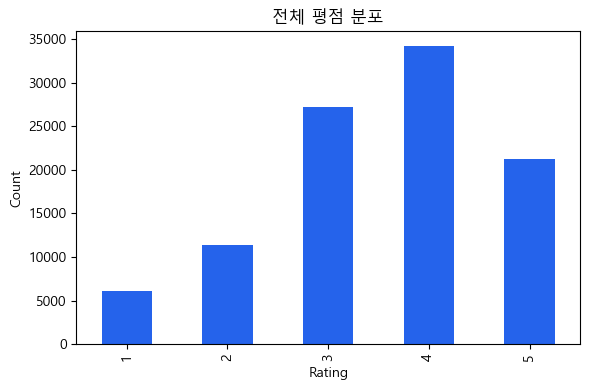

count    100000.000000
mean          3.529860
std           1.125674
min           1.000000
25%           3.000000
50%           4.000000
75%           4.000000
max           5.000000
Name: rating, dtype: float64
왜도(skew): -0.5101439492170148


In [19]:
fig, ax = plt.subplots(figsize=(6, 4))
ratings["rating"].value_counts().sort_index().plot(kind="bar", ax=ax, color="#2563eb")
ax.set_title("전체 평점 분포")
ax.set_xlabel("Rating")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

print(ratings["rating"].describe())
print("왜도(skew):", ratings["rating"].skew())

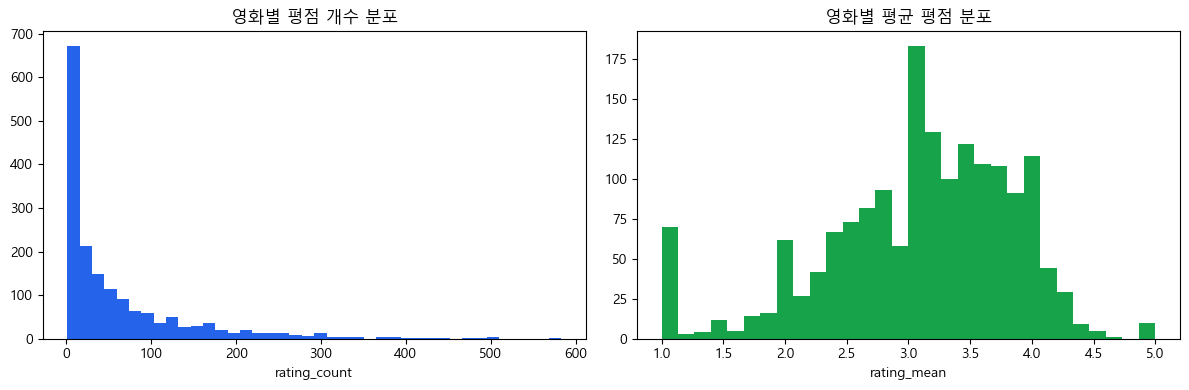

count    1682.000000
mean       59.453032
std        80.383846
min         1.000000
25%         6.000000
50%        27.000000
75%        80.000000
max       583.000000
Name: rating_count, dtype: float64
왜도(rating_count): 2.313047043543274


In [20]:
movie_stats = ratings.groupby("movie_id")["rating"].agg(rating_count="count", rating_mean="mean")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(movie_stats["rating_count"], bins=40, color="#2563eb")
axes[0].set_title("영화별 평점 개수 분포")
axes[0].set_xlabel("rating_count")

axes[1].hist(movie_stats["rating_mean"], bins=30, color="#16a34a")
axes[1].set_title("영화별 평균 평점 분포")
axes[1].set_xlabel("rating_mean")
plt.tight_layout()
plt.show()

print(movie_stats["rating_count"].describe())
print("왜도(rating_count):", movie_stats["rating_count"].skew())

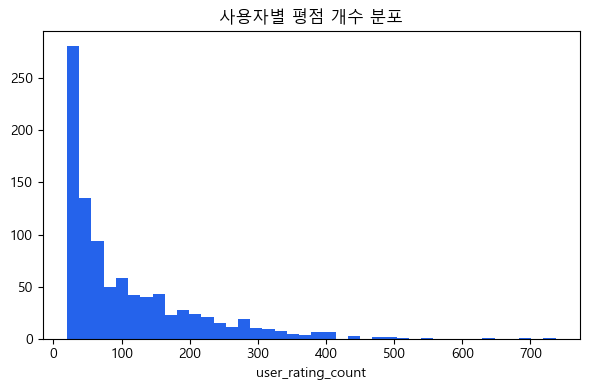

count    943.000000
mean     106.044539
std      100.931743
min       20.000000
25%       33.000000
50%       65.000000
75%      148.000000
max      737.000000
Name: user_rating_count, dtype: float64
왜도(user_rating_count): 1.9056092374247244


In [26]:
user_stats = ratings.groupby("user_id")["rating"].agg(user_rating_count="count", user_rating_mean="mean")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(user_stats["user_rating_count"], bins=40, color="#2563eb")
ax.set_title("사용자별 평점 개수 분포")
ax.set_xlabel("user_rating_count")
plt.tight_layout()
plt.show()

print(user_stats["user_rating_count"].describe())
print("왜도(user_rating_count):", user_stats["user_rating_count"].skew())

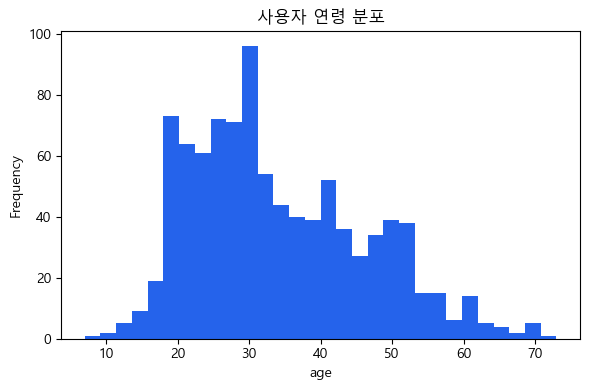

count    943.000000
mean      34.051962
std       12.192740
min        7.000000
25%       25.000000
50%       31.000000
75%       43.000000
max       73.000000
Name: age, dtype: float64
성별 분포:
gender
M    670
F    273
Name: count, dtype: int64


In [21]:
fig, ax = plt.subplots(figsize=(6, 4))
users["age"].plot(kind="hist", bins=30, ax=ax, color="#2563eb")
ax.set_title("사용자 연령 분포")
ax.set_xlabel("age")
plt.tight_layout()
plt.show()

print(users["age"].describe())
print("성별 분포:")
print(users["gender"].value_counts())

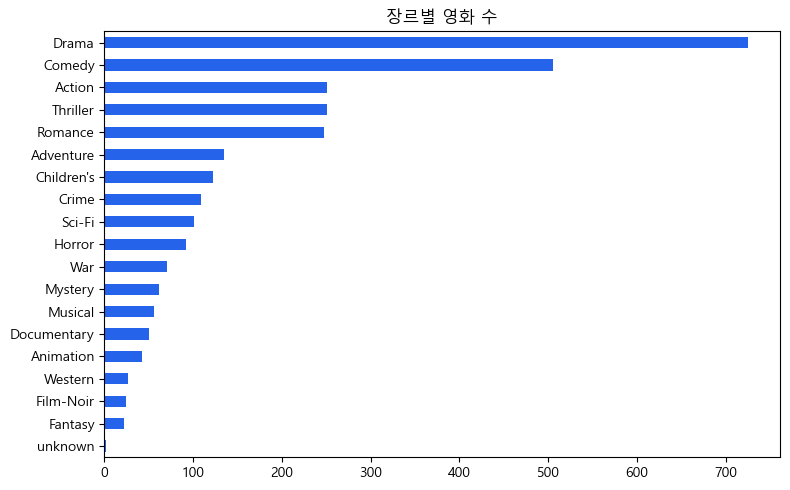

Drama          725
Comedy         505
Action         251
Thriller       251
Romance        247
Adventure      135
Children's     122
Crime          109
Sci-Fi         101
Horror          92
War             71
Mystery         61
Musical         56
Documentary     50
Animation       42
Western         27
Film-Noir       24
Fantasy         22
unknown          2
dtype: int64

In [22]:
genre_counts = movies[GENRE_COLUMNS].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
genre_counts.plot(kind="barh", ax=ax, color="#2563eb")
ax.invert_yaxis()
ax.set_title("장르별 영화 수")
plt.tight_layout()
plt.show()

genre_counts

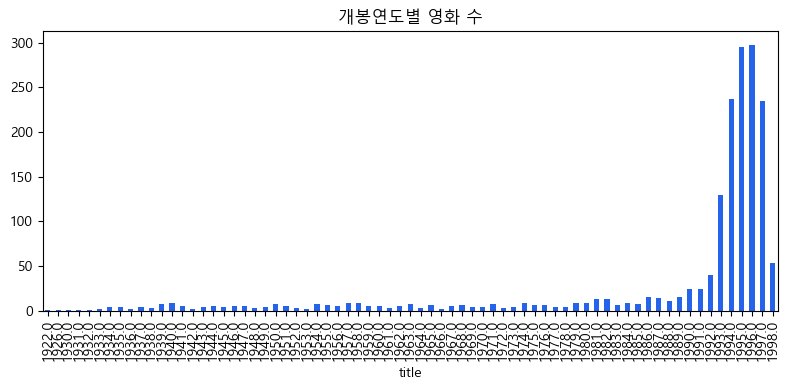

count    1680.000000
mean     1989.067857
std        14.305363
min      1922.000000
25%      1992.000000
50%      1995.000000
75%      1996.000000
max      1998.000000
Name: title, dtype: float64

In [23]:
years = movies["title"].apply(lambda t: split_title_and_year(t)[1])
years = pd.Series(years, index=movies["movie_id"]).dropna()

fig, ax = plt.subplots(figsize=(8, 4))
years.value_counts().sort_index().plot(kind="bar", ax=ax, color="#2563eb")
ax.set_title("개봉연도별 영화 수")
plt.tight_layout()
plt.show()

years.describe()

개봉연도는 1990년대 중반(1994~1997)에 크게 몰려 있습니다. MovieLens 100K는 1997~1998년 무렵 수집된
데이터셋이라, 수집 시점 근처의 "최신 개봉작"이 많이 포함되어 있고 오래된 고전 영화(1920~1980년대)는
상대적으로 적습니다. 이는 실제 데이터 수집 시점의 특성이며, 이 서비스가 "최신 영화 추천"보다는
"1990년대 데이터 기준 유사 영화 추천"에 가깝다는 점을 사용자에게 안내할 필요가 있습니다.

## 9. 이상치 분석

추천 데이터에서 "이상치"는 잘못된 값이 아니라 정상적인 극단값(매우 인기 있는 영화, 매우 적극적인
사용자)인 경우가 많습니다. 무조건 제거하지 않고, Box Plot으로 확인한 뒤 각각의 의미를 판단합니다.

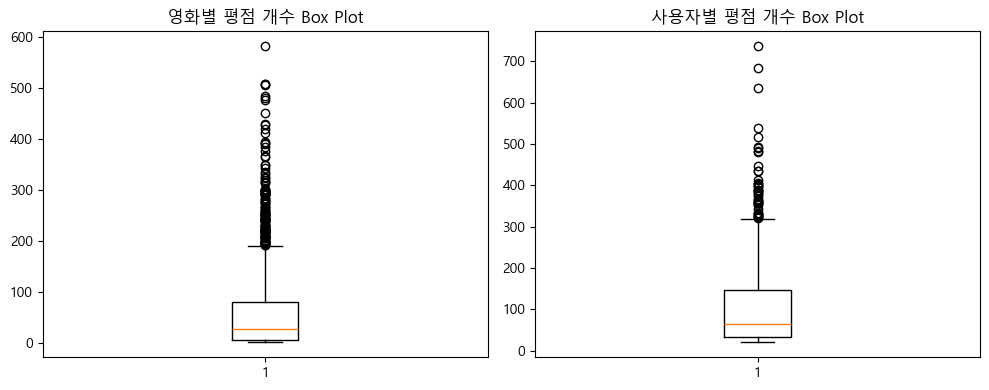

가장 많이 평가된 영화: Star Wars (1977) (583건)
가장 활발한 사용자: 405 (737건 평가)


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].boxplot(movie_stats["rating_count"], orientation="vertical")
axes[0].set_title("영화별 평점 개수 Box Plot")

axes[1].boxplot(user_stats["user_rating_count"], orientation="vertical")
axes[1].set_title("사용자별 평점 개수 Box Plot")
plt.tight_layout()
plt.show()

most_rated = movie_stats["rating_count"].idxmax()
print("가장 많이 평가된 영화:", movies.set_index("movie_id").loc[most_rated, "title"],
      f"({movie_stats.loc[most_rated, 'rating_count']}건)")

most_active_user = user_stats["user_rating_count"].idxmax()
print("가장 활발한 사용자:", most_active_user,
      f"({user_stats.loc[most_active_user, 'user_rating_count']}건 평가)")

## 10. 왜도 분석

앞서 확인한 왜도 값을 정리하고, 로그 변환이 실제로 도움이 되는지 시각적으로 비교합니다.

In [28]:
skew_table = pd.DataFrame({
    "column": ["rating", "movie_rating_count", "user_rating_count", "age"],
    "skew": [
        ratings["rating"].skew(),
        movie_stats["rating_count"].skew(),
        user_stats["user_rating_count"].skew(),
        users["age"].skew(),
    ],
})
skew_table

,column,skew
0,rating,-0.510144
1,movie_rating_count,2.313047
2,user_rating_count,1.905609
3,age,0.605382


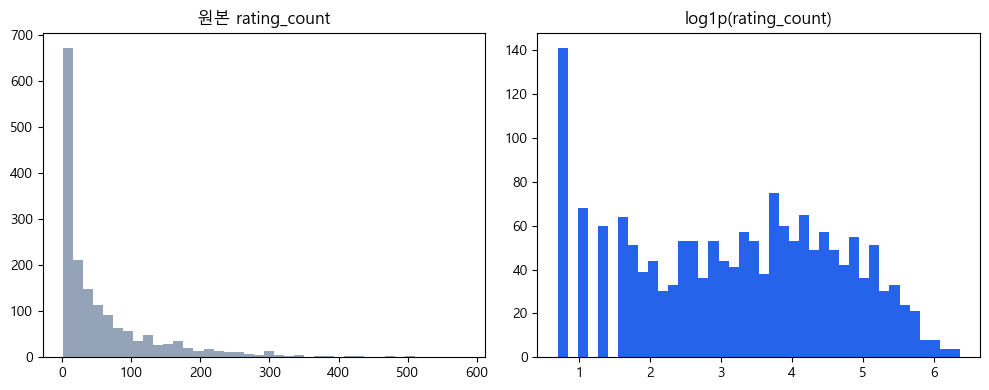

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(movie_stats["rating_count"], bins=40, color="#94a3b8")
axes[0].set_title("원본 rating_count")

axes[1].hist(np.log1p(movie_stats["rating_count"]), bins=40, color="#2563eb")
axes[1].set_title("log1p(rating_count)")
plt.tight_layout()
plt.show()

# Feature Engineering

EDA에서 확인한 특성을 바탕으로, 추천 품질을 개선하기 위한 Feature Engineering을 진행합니다.
모든 로직은 `feature_engineering.py`에 구현되어 있으며, Notebook과 `train_model.py`/`main.py`가
동일한 함수를 그대로 가져다 씁니다.

## 14.1 영화별 평점 개수 (`rating_count`)


In [30]:
movie_metadata_preview = build_movie_metadata(movies, ratings)
movie_metadata_preview[["title", "rating_count", "rating_mean"]].sort_values(
    "rating_mean", ascending=False
).head(10)

,title,rating_count,rating_mean
movie_id,,,
814,"Great Day in Harlem, A (1994)",1,5.0
1599,Someone Else's America (1995),1,5.0
1201,Marlene Dietrich: Shadow and Light (1996),1,5.0
1122,They Made Me a Criminal (1939),1,5.0
1653,Entertaining Angels: The Dorothy Day Story (1996),1,5.0
1293,Star Kid (1997),3,5.0
1500,Santa with Muscles (1996),2,5.0
1189,Prefontaine (1997),3,5.0
1536,Aiqing wansui (1994),1,5.0


실제로 위 표에는 평점 5.0점이지만 평가 수가 1~2건에 불과한 영화들이 상위권을 차지하고 있습니다.
이것이 바로 "평균 평점만으로 추천하면 안 되는" 대표적인 사례입니다.

## 14.2 영화별 평균 평점 (`rating_mean`)

`rating_mean`은 영화 품질을 나타내는 핵심 지표지만, 위에서 보듯 평점 개수와 함께 보지 않으면
왜곡된 인기 영화 순위를 만들어냅니다. 인기도 점수(15.1절)에서는 이 문제를 Bayesian Weighted Rating
공식으로 보정합니다.

## 14.3 최소 평점 수 기준

협업 필터링 유사도 행렬에 포함할 영화를 정하기 위해, `rating_count`의 분포를 다시 확인합니다.

In [31]:
quantiles = [0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 0.95]
rc = movie_metadata_preview["rating_count"]
quantile_table = pd.DataFrame({
    "quantile": quantiles,
    "rating_count": [rc.quantile(q) for q in quantiles],
})
print(quantile_table)
print()
print(f"rating_count < 5  인 영화: {(rc < 5).sum()}편")
print(f"rating_count < 20 인 영화: {(rc < 20).sum()}편")
print(f"rating_count >= 20 인 영화: {(rc >= 20).sum()}편")

   quantile  rating_count
0      0.50         27.00
1      0.60         43.00
2      0.70         65.00
3      0.75         80.00
4      0.80        100.00
5      0.90        169.00
6      0.95        229.85

rating_count < 5  인 영화: 333편
rating_count < 20 인 영화: 743편
rating_count >= 20 인 영화: 939편


## 14.5 영화 제목 정리 / 14.6 개봉연도 추출

`u.item`의 제목은 `"Toy Story (1995)"`처럼 개봉연도가 포함된 형태입니다. 검색 UX와 화면 표시를 위해
제목과 연도를 분리합니다. 앞서 살펴본 대로 `"unknown"`(연도 없음)과
`"...(1995) (V)"`(연도 뒤에 부가 표기) 같은 예외 케이스도 안전하게 처리해야 합니다.

In [32]:
examples = [1, 267, 1407]  # Toy Story / unknown / Land Before Time III (V 표기 포함)
for movie_id in examples:
    raw_title = movies.set_index("movie_id").loc[movie_id, "title"]
    clean, year = split_title_and_year(raw_title)
    print(f"{raw_title!r:55s} -> clean={clean!r}, year={year}")

'Toy Story (1995)'                                      -> clean='Toy Story', year=1995
'unknown'                                               -> clean='unknown', year=None
'Specialist, The (1994)'                                -> clean='Specialist, The', year=1994


In [33]:
genre_matrix_preview = build_genre_matrix(movies)
print("장르 행렬 크기:", genre_matrix_preview.shape)
genre_matrix_preview.loc[[1, 50, 172]]  # Toy Story, Star Wars, Empire Strikes Back

장르 행렬 크기: (1682, 19)


,unknown,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
movie_id,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
172,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0


한 영화가 여러 장르를 가질 수 있으므로(13.8절에서 평균 1.72개), 장르 벡터의 코사인 유사도를 계산하면
공통 장르가 많을수록 1에 가까운 값이 나옵니다. 이 벡터가 콘텐츠 기반 추천(15.2절)의 입력입니다.

## 14.8 사용자-영화 평점 행렬

협업 필터링을 위해 행=사용자, 열=영화, 값=평점인 행렬을 만듭니다. 작은 예시로 개념을 먼저
확인합니다.

In [34]:
# 작은 장난감 예시: 사용자 3명, 영화 4편
toy_example = pd.DataFrame(
    {
        "movie_A": [5, 4, np.nan],
        "movie_B": [4, np.nan, 2],
        "movie_C": [np.nan, 5, 1],
        "movie_D": [1, 2, 5],
    },
    index=["user_1", "user_2", "user_3"],
)
toy_example

,movie_A,movie_B,movie_C,movie_D
user_1,5.0,4.0,NaN,1
user_2,4.0,NaN,5.0,2
user_3,NaN,2.0,1.0,5


- **행(사용자)**: 각 사용자가 남긴 평점 벡터
- **열(영화)**: 각 영화가 받은 평점 벡터 (협업 필터링에서는 이 열끼리 유사도를 계산합니다)
- **결측값(NaN)**: 아직 평가하지 않은 칸. **0으로 채우면 "0점을 줬다"는 의미로 오해될 수 있어 위험**
  합니다. 그래서 사용자 평균으로 중심화(centering)한 뒤에만 0으로 채웁니다(아래 참고).
- **희소성(Sparsity)**: 실제 데이터는 943명 x 1,682편 중 단 10만 개(약 6.3%)만 채워져 있어
  매우 희소(sparse)합니다.

In [35]:
user_item_matrix_preview = build_user_item_matrix(ratings)
print("사용자-영화 행렬 크기:", user_item_matrix_preview.shape)
filled_ratio = user_item_matrix_preview.notna().sum().sum() / user_item_matrix_preview.size
print(f"채워진 비율: {filled_ratio * 100:.2f}%")

centered_preview = mean_center_user_item_matrix(user_item_matrix_preview)
centered_preview.iloc[:5, :5]

사용자-영화 행렬 크기: (943, 1682)
채워진 비율: 6.30%


movie_id,1,2,3,4,5
user_id,,,,,
1,1.389706,-0.610294,0.389706,-0.610294,-0.610294
2,0.290323,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.000000
5,1.125714,0.125714,0.000000,0.000000,0.000000




## 14.9 영화 Feature 행렬

콘텐츠 기반 추천을 위한 장르 벡터(14.7절의 `genre_matrix`)로 코사인 유사도를 바로 계산할 수 있는
형태를 이미 만들어 두었습니다. 예시로 Toy Story와 다른 두 영화의 유사도를 계산해봅니다.

In [36]:
toy_story_vec = genre_matrix_preview.loc[[1]]
comparison_ids = [95, 318]  # Aladdin(애니메이션/코미디), Schindler's List(드라마/전쟁)
comparison_vecs = genre_matrix_preview.loc[comparison_ids]

sims = cosine_similarity(toy_story_vec, comparison_vecs)[0]
for movie_id, sim in zip(comparison_ids, sims):
    title = movies.set_index("movie_id").loc[movie_id, "title"]
    print(f"Toy Story vs {title}: 유사도 {sim:.3f}")

Toy Story vs Aladdin (1992): 유사도 0.866
Toy Story vs Schindler's List (1993): 유사도 0.000




## 14.10 Feature Engineering 전후 비교

지금까지 적용한 Feature Engineering을 정리합니다.

In [37]:
fe_summary = pd.DataFrame([
    {"단계": "rating_count/rating_mean", "목적": "영화 신뢰도/품질 파악", "비고": "평균 평점의 착시 방지"},
    {"단계": "popularity_score (Bayesian)", "목적": "평점 수와 평균을 함께 반영한 인기도", "비고": "15.1절"},
    {"단계": "최소 평점 수 필터 (>=20)", "목적": "협업 필터링 신뢰도 확보", "비고": f"{(movie_metadata_preview['rating_count'] >= 20).sum()}/{len(movie_metadata_preview)}편 대상"},
    {"단계": "clean_title/release_year/search_title", "목적": "검색 UX, 화면 표시", "비고": "유사도 계산에는 미사용"},
    {"단계": "genre_matrix (Multi-Hot)", "목적": "콘텐츠 기반 추천 입력", "비고": "14.7, 14.9절"},
    {"단계": "user_item_matrix (평균 중심화)", "목적": "협업 필터링 입력", "비고": "14.8절"},
])
fe_summary

,단계,목적,비고
0,rating_count/rating_mean,영화 신뢰도/품질 파악,평균 평점의 착시 방지
1,popularity_score (Bayesian),평점 수와 평균을 함께 반영한 인기도,15.1절
2,최소 평점 수 필터 (>=20),협업 필터링 신뢰도 확보,939/1682편 대상
3,clean_title/release_year/search_title,"검색 UX, 화면 표시",유사도 계산에는 미사용
4,genre_matrix (Multi-Hot),콘텐츠 기반 추천 입력,"14.7, 14.9절"
5,user_item_matrix (평균 중심화),협업 필터링 입력,14.8절


# 추천 알고리즘 구현

세 가지 추천 방식을 순서대로 구현하고 각각 예시로 확인합니다.

## 15.1 Popularity-Based Recommendation

평균 평점과 평점 수를 함께 반영한 **Bayesian Weighted Rating**(IMDB 공식과 동일한 형태)으로 인기
영화를 계산합니다.

```
weighted = (v / (v + m)) * R + (m / (v + m)) * C
```

- `v`: 해당 영화의 평점 수, `R`: 해당 영화의 평균 평점
- `m`: 최소 투표 수 기준 (rating_count의 60번째 백분위수로 데이터 기반 결정)
- `C`: 전체 영화 평균 평점

로그인이나 시청 이력이 없는 신규 사용자에게 보여줄 수 있는 기본 추천 전략입니다.

In [38]:
popularity_score, m, C = compute_bayesian_popularity(
    movie_metadata_preview["rating_count"], movie_metadata_preview["rating_mean"]
)
movie_metadata_preview["popularity_score"] = popularity_score

print(f"최소 투표 수 기준 m = {m:.2f}건 (rating_count의 60번째 백분위수)")
print(f"전체 영화 평균 C = {C:.4f}")

top_popular = movie_metadata_preview.sort_values("popularity_score", ascending=False).head(10)
top_popular[["title", "rating_count", "rating_mean", "popularity_score"]]

최소 투표 수 기준 m = 43.00건 (rating_count의 60번째 백분위수)
전체 영화 평균 C = 3.0760


,title,rating_count,rating_mean,popularity_score
movie_id,,,,
318,Schindler's List (1993),298,4.466443,4.291114
50,Star Wars (1977),583,4.358491,4.270399
64,"Shawshank Redemption, The (1994)",283,4.445230,4.264632
483,Casablanca (1942),243,4.456790,4.249196
12,"Usual Suspects, The (1995)",267,4.385768,4.204096
127,"Godfather, The (1972)",413,4.283293,4.169452
98,"Silence of the Lambs, The (1991)",390,4.289744,4.169215
603,Rear Window (1954),209,4.387560,4.163769
174,Raiders of the Lost Ark (1981),420,4.252381,4.143132


단순 평균 평점 순위(14.1절)와 달리, 평점 수가 극단적으로 적은 영화가 상위권에서 사라지고 실제로
잘 알려진 명작 위주로 순위가 형성되는 것을 확인할 수 있습니다.

## 15.2 Content-Based Recommendation

영화 장르 벡터의 코사인 유사도를 기반으로 추천합니다. 자기 자신은 제외하고 상위 N개를 추천합니다.

In [39]:
def recommend_content_based(movie_id, top_n=10):
    target_vector = genre_matrix_preview.loc[[movie_id]]
    candidates = genre_matrix_preview.drop(index=movie_id)

    scores = cosine_similarity(target_vector, candidates)[0]
    similarity = pd.Series(scores, index=candidates.index).sort_values(ascending=False).head(top_n)

    base_genres = set(movie_metadata_preview.loc[movie_id, "genres"])
    rows = []
    for candidate_id, score in similarity.items():
        candidate = movie_metadata_preview.loc[candidate_id]
        common = [g for g in candidate["genres"] if g in base_genres]
        reason = (
            f"선택한 영화와 {', '.join(common)} 장르가 유사합니다."
            if common else "선택한 영화와 장르 구성이 유사합니다."
        )
        rows.append({
            "movie_id": candidate_id, "title": candidate["title"],
            "similarity_score": round(float(score), 4), "genres": candidate["genres"],
            "average_rating": round(float(candidate["rating_mean"]), 2),
            "rating_count": int(candidate["rating_count"]),
            "recommendation_reason": reason,
        })
    return pd.DataFrame(rows)


recommend_content_based(1, top_n=5)  # Toy Story (1995)

,movie_id,title,similarity_score,genres,average_rating,rating_count,recommendation_reason
0,422,Aladdin and the King of Thieves (1996),1.0000,"[Animation, Children's, Comedy]",2.85,26,"선택한 영화와 Animation, Children's, Comedy 장르가 유사합니다."
1,1219,"Goofy Movie, A (1995)",0.8660,"[Animation, Children's, Comedy, Romance]",2.90,20,"선택한 영화와 Animation, Children's, Comedy 장르가 유사합니다."
2,95,Aladdin (1992),0.8660,"[Animation, Children's, Comedy, Musical]",3.81,219,"선택한 영화와 Animation, Children's, Comedy 장르가 유사합니다."
3,94,Home Alone (1990),0.8165,"[Children's, Comedy]",3.09,137,"선택한 영화와 Children's, Comedy 장르가 유사합니다."
4,383,"Flintstones, The (1994)",0.8165,"[Children's, Comedy]",2.06,31,"선택한 영화와 Children's, Comedy 장르가 유사합니다."


## 15.3 Collaborative Filtering (Item-Based)

사용자가 로그인하거나 평점을 입력하지 않고 영화 한 편만 선택해 추천받는 서비스 구조이므로,
**Item-Based Collaborative Filtering**을 사용합니다. 사용자 프로필이 아니라 "영화 간 유사도"를
직접 계산하기 때문에, 이 서비스의 "영화 하나 선택 -> 유사 영화 추천" 흐름과 정확히 맞습니다.

평점이 충분한 영화(14.3절 기준, `rating_count >= 20`)만 대상으로 사용자 평균 중심화 코사인 유사도를
계산합니다.

In [40]:
rating_count_all = ratings.groupby("movie_id")["rating"].count()
eligible_movie_ids = rating_count_all[rating_count_all >= MIN_RATING_COUNT_FOR_CF].index

user_item_matrix_cf = build_user_item_matrix(ratings)
user_item_matrix_cf = user_item_matrix_cf[[c for c in user_item_matrix_cf.columns if c in eligible_movie_ids]]

centered_cf = mean_center_user_item_matrix(user_item_matrix_cf)
movie_vectors_cf = centered_cf.T  # 행: 영화, 열: 사용자

item_similarity = pd.DataFrame(
    cosine_similarity(movie_vectors_cf),
    index=movie_vectors_cf.index,
    columns=movie_vectors_cf.index,
)

print("Item-Based CF 유사도 행렬 크기:", item_similarity.shape)

Item-Based CF 유사도 행렬 크기: (939, 939)


In [41]:
def recommend_item_based_cf(movie_id, top_n=10):
    if movie_id not in item_similarity.index:
        raise KeyError(f"movie_id={movie_id}는 평점 수가 부족해 협업 필터링 대상이 아닙니다 (Cold Start).")

    similarity = item_similarity.loc[movie_id].drop(labels=[movie_id]).sort_values(ascending=False).head(top_n)

    base_genres = set(movie_metadata_preview.loc[movie_id, "genres"])
    rows = []
    for candidate_id, score in similarity.items():
        candidate = movie_metadata_preview.loc[candidate_id]
        common = [g for g in candidate["genres"] if g in base_genres]
        reason = (
            f"이 영화를 좋아한 다른 사용자들이 함께 높게 평가한 영화입니다. (공통 장르: {', '.join(common)})"
            if common else "이 영화를 좋아한 다른 사용자들이 함께 높게 평가한 영화입니다."
        )
        rows.append({
            "movie_id": candidate_id, "title": candidate["title"],
            "similarity_score": round(float(score), 4), "genres": candidate["genres"],
            "average_rating": round(float(candidate["rating_mean"]), 2),
            "rating_count": int(candidate["rating_count"]),
            "recommendation_reason": reason,
        })
    return pd.DataFrame(rows)


recommend_item_based_cf(1, top_n=5)  # Toy Story (1995)

,movie_id,title,similarity_score,genres,average_rating,rating_count,recommendation_reason
0,174,Raiders of the Lost Ark (1981),0.2596,"[Action, Adventure]",4.25,420,이 영화를 좋아한 다른 사용자들이 함께 높게 평가한 영화입니다.
1,588,Beauty and the Beast (1991),0.2291,"[Animation, Children's, Musical]",3.79,202,"이 영화를 좋아한 다른 사용자들이 함께 높게 평가한 영화입니다. (공통 장르: Animation, Children's)"
2,50,Star Wars (1977),0.2219,"[Action, Adventure, Romance, Sci-Fi, War]",4.36,583,이 영화를 좋아한 다른 사용자들이 함께 높게 평가한 영화입니다.
3,28,Apollo 13 (1995),0.2175,"[Action, Drama, Thriller]",3.93,276,이 영화를 좋아한 다른 사용자들이 함께 높게 평가한 영화입니다.
4,95,Aladdin (1992),0.2029,"[Animation, Children's, Comedy, Musical]",3.81,219,"이 영화를 좋아한 다른 사용자들이 함께 높게 평가한 영화입니다. (공통 장르: Animation, Children's, Comedy)"


In [42]:
cold_start_movie_id = movie_metadata_preview[movie_metadata_preview["rating_count"] < MIN_RATING_COUNT_FOR_CF].index[0]
try:
    recommend_item_based_cf(cold_start_movie_id, top_n=5)
except KeyError as error:
    print("예상된 예외 발생:", error)
    print()
    print("-> 콘텐츠 기반 추천으로 대체:")
    display(recommend_content_based(cold_start_movie_id, top_n=5))

예상된 예외 발생: 'movie_id=18는 평점 수가 부족해 협업 필터링 대상이 아닙니다 (Cold Start).'

-> 콘텐츠 기반 추천으로 대체:


,movie_id,title,similarity_score,genres,average_rating,rating_count,recommendation_reason
0,1682,Scream of Stone (Schrei aus Stein) (1991),1.0,[Drama],3.00,1,선택한 영화와 Drama 장르가 유사합니다.
1,1171,Wild Reeds (1994),1.0,[Drama],3.14,14,선택한 영화와 Drama 장르가 유사합니다.
2,375,Showgirls (1995),1.0,[Drama],1.96,23,선택한 영화와 Drama 장르가 유사합니다.
3,1189,Prefontaine (1997),1.0,[Drama],5.00,3,선택한 영화와 Drama 장르가 유사합니다.
4,1192,"Boys of St. Vincent, The (1993)",1.0,[Drama],3.38,13,선택한 영화와 Drama 장르가 유사합니다.


# 추천 알고리즘 비교

세 방식을 정성적 기준(개인화 수준, Cold Start 대응 등)과 정량적 기준(Precision@K, Recall@K)으로
비교합니다.

## 16.1 정성적 비교

| 기준 | Popularity | Content-Based | Item-Based CF |
|---|---|---|---|
| 개인화 수준 | 없음 (전체 동일) | 있음 (장르 기반) | 있음 (행동 패턴 기반) |
| 결과 다양성 | 낮음 (항상 동일 상위권) | 중간 | 중간~높음 |
| 신규 사용자 대응 | 강함 | 강함 | 강함 (사용자 프로필 불필요) |
| 신규 영화 대응(Cold Start) | 불가(평점 없으면 계산 불가) | 강함 (장르만 있으면 가능) | 불가 (평점 부족 시 계산 불가) |
| 결과 설명 가능성 | 높음 ("평점이 높아서") | 높음 ("장르가 같아서") | 중간 ("함께 평가되어서") |
| 계산 비용 | 매우 낮음 | 낮음 | 중간 (유사도 행렬 사전 계산 필요) |
| 서비스 구조 적합성(영화 1편 선택) | 낮음 (선택과 무관하게 동일 결과) | 있음 | 높음 |

## 16.2 정량적 비교 (Precision@K / Recall@K)

MovieLens 100K가 공식으로 제공하는 `ua.base`(학습용) / `ua.test`(평가용, 사용자별 10건) 분할을
사용합니다. 각 사용자에 대해 `ua.base`에서 가장 높게 평가한 영화 1편을 "선택한 영화"로 가정하고,
그 영화를 기준으로 추천한 Top-10이 `ua.test`에서 그 사용자가 실제로 높게(4점 이상) 평가한 영화와
얼마나 겹치는지 측정합니다. 이는 로그인이나 전체 시청 이력 없이 "영화 한 편 선택 -> 추천"만 제공하는
이 서비스의 실제 사용 흐름을 그대로 재현한 평가 방식입니다.

데이터 누수 방지를 위해, 유사도 행렬(Item-Based CF)과 인기도 점수(Popularity)는 반드시 `ua.base`
(학습 데이터)만으로 계산하고, 그 사용자가 `ua.base`에서 이미 본 영화는 추천 후보에서 제외합니다.

In [43]:
def load_official_split(filename):
    return pd.read_csv(data_dir / filename, sep="\t", names=RATING_COLUMNS)


train_split = load_official_split("ua.base")
test_split = load_official_split("ua.test")
print("ua.base:", train_split.shape, " ua.test:", test_split.shape)

ua.base: (90570, 4)  ua.test: (9430, 4)


In [44]:
# 1) ua.base만으로 인기도 / 콘텐츠 / 협업 필터링 유사도를 다시 계산한다 (평가 전용, 운영 모델과 별개).
eval_metadata = build_movie_metadata(movies, train_split)
eval_popularity, eval_m, eval_C = compute_bayesian_popularity(
    eval_metadata["rating_count"], eval_metadata["rating_mean"]
)
eval_metadata["popularity_score"] = eval_popularity
eval_top_popular = eval_metadata.sort_values("popularity_score", ascending=False).index.tolist()

eval_rc = train_split.groupby("movie_id")["rating"].count()
eval_eligible = eval_rc[eval_rc >= MIN_RATING_COUNT_FOR_CF].index
eval_uim = build_user_item_matrix(train_split)
eval_uim = eval_uim[[c for c in eval_uim.columns if c in eval_eligible]]
eval_centered = mean_center_user_item_matrix(eval_uim)
eval_item_sim = pd.DataFrame(
    cosine_similarity(eval_centered.T), index=eval_centered.columns, columns=eval_centered.columns
)
print("평가용 Item-Based CF 행렬 크기:", eval_item_sim.shape)

평가용 Item-Based CF 행렬 크기: (918, 918)


In [45]:
# 2) 사용자별 "선택 영화"(ua.base에서 가장 높게 평가한 영화)와 "정답 집합"(ua.test에서 4점 이상)을 만든다.
TOP_K = 10

train_liked = train_split[train_split["rating"] >= 4]
test_liked = test_split[test_split["rating"] >= 4]

user_seed_movie = {}
for user_id, group in train_liked.groupby("user_id"):
    row = group.sort_values(["rating", "timestamp"], ascending=[False, False]).iloc[0]
    user_seed_movie[user_id] = int(row["movie_id"])

user_relevant_set = {user_id: set(group["movie_id"]) for user_id, group in test_liked.groupby("user_id")}
user_seen_in_train = {user_id: set(group["movie_id"]) for user_id, group in train_split.groupby("user_id")}

print(f"평가 대상 사용자 수: {len(user_relevant_set)}")

평가 대상 사용자 수: 934


In [46]:
def eval_content_recs(movie_id, top_n, exclude):
    if movie_id not in genre_matrix_preview.index:
        return []
    target = genre_matrix_preview.loc[[movie_id]]
    candidates = genre_matrix_preview.drop(index=list({movie_id} | exclude), errors="ignore")
    scores = cosine_similarity(target, candidates)[0]
    return pd.Series(scores, index=candidates.index).sort_values(ascending=False).head(top_n).index.tolist()


def eval_cf_recs(movie_id, top_n, exclude):
    if movie_id not in eval_item_sim.index:
        return None
    sims = eval_item_sim.loc[movie_id].drop(labels=list({movie_id} | exclude), errors="ignore")
    return sims.sort_values(ascending=False).head(top_n).index.tolist()


def eval_popularity_recs(top_n, exclude):
    return [m for m in eval_top_popular if m not in exclude][:top_n]


scores_by_algorithm = {"popularity": [], "content_based": [], "item_based_cf": []}
cf_coverage, total_evaluated = 0, 0

for user_id, relevant in user_relevant_set.items():
    if user_id not in user_seed_movie:
        continue
    seed_movie = user_seed_movie[user_id]
    seen = user_seen_in_train.get(user_id, set())
    total_evaluated += 1

    pop_recs = eval_popularity_recs(TOP_K, exclude=seen)
    hits = len(set(pop_recs) & relevant)
    scores_by_algorithm["popularity"].append((hits / TOP_K, hits / len(relevant)))

    content_recs_result = eval_content_recs(seed_movie, TOP_K, exclude=seen | {seed_movie})
    hits = len(set(content_recs_result) & relevant)
    scores_by_algorithm["content_based"].append((hits / TOP_K, hits / len(relevant)))

    cf_recs_result = eval_cf_recs(seed_movie, TOP_K, exclude=seen | {seed_movie})
    if cf_recs_result is not None:
        cf_coverage += 1
        hits = len(set(cf_recs_result) & relevant)
        scores_by_algorithm["item_based_cf"].append((hits / TOP_K, hits / len(relevant)))

comparison_rows = []
for name, values in scores_by_algorithm.items():
    precisions = [v[0] for v in values]
    recalls = [v[1] for v in values]
    comparison_rows.append({
        "algorithm": name,
        "evaluated_users": len(values),
        f"precision@{TOP_K}": round(float(np.mean(precisions)), 4),
        f"recall@{TOP_K}": round(float(np.mean(recalls)), 4),
    })

print(f"전체 평가 대상 사용자: {total_evaluated}, CF 적용 가능(seed가 평점 20건 이상): {cf_coverage}"
      f" ({cf_coverage / total_evaluated * 100:.1f}%)")
pd.DataFrame(comparison_rows)

전체 평가 대상 사용자: 934, CF 적용 가능(seed가 평점 20건 이상): 906 (97.0%)


,algorithm,evaluated_users,precision@10,recall@10
0,popularity,934,0.0468,0.0815
1,content_based,934,0.0102,0.0167
2,item_based_cf,906,0.0417,0.0726


### 결과 해석

- **Popularity(인기 기반)**가 Precision@10=0.0468, Recall@10=0.0815로, 오히려 Item-Based CF
  (Precision@10=0.0417, Recall@10=0.0726)보다 근소하게 더 높은 수치를 보입니다. 이는 추천 시스템
  연구에서 잘 알려진 현상으로, **인기도는 매우 강력한 baseline**입니다 - 많은 사용자가 실제로 유명한
  영화를 좋아하기 때문에, "가장 인기 있는 영화 10편"을 추천하는 것만으로도 꽤 높은 적중률을 기록합니다.
- 그러나 Popularity는 **선택한 영화가 무엇이든 항상 동일한 목록**을 추천합니다. "Toy Story를 골랐을
  때"와 "Schindler's List를 골랐을 때" 추천 결과가 똑같다면, "영화 한 편을 선택해서 유사한 영화를
  추천받는다"는 이 서비스의 핵심 가치를 제공하지 못합니다. 지표상 근소하게 앞선다는 이유만으로
  Popularity를 최종 알고리즘으로 선택하지 않는 이유입니다.
- **Content-Based(장르 기반)**는 정량적 지표가 세 방식 중 가장 낮습니다(Precision@10=0.0102,
  Recall@10=0.0167). 장르가 같다고 해서 실제로 사용자가 함께 좋아하는 것은 아니기 때문입니다(예:
  코미디를 좋아하는 사용자가 모든 코미디 영화를 좋아하지는 않습니다). 다만 **평점 데이터가 없는
  영화에도 항상 적용할 수 있다**는 유일한 방법입니다.
- **Item-Based CF**는 정량 지표만 보면 Popularity에 근소하게 못 미치지만(같은 자릿수 범위로 큰 차이는
  아닙니다), **선택한 영화에 따라 실제로 다른 추천 결과**를 만들어 낸다는 점에서 이 서비스에 가장
  적합합니다. 다만 평점이 20건 미만인 영화(전체의 약 44%가량)에는 적용할 수 없다는 한계가 있습니다.

**참고**: 위 정량 지표(Precision@10, Recall@10 모두 0.01~0.08 수준)는 절대적으로 높은 수치가
아닙니다. 이는 "사용자의 전체 시청 이력"이 아니라 "영화 딱 한 편"만으로 예측하는, 이 서비스와 동일한
매우 제한적인 조건에서 평가했기 때문입니다. 전체 이력을 사용하는 일반적인 추천 시스템 평가보다
지표가 낮게 나오는 것이 자연스러우며, 지표의 절대값보다 **알고리즘 간 상대적 비교**와 **서비스 구조
적합성**을 함께 고려한 선택이라는 점이 중요합니다.

# 최종 추천 모델 선정

## 최종 선택: Item-Based Collaborative Filtering + Content-Based(장르) Fallback

**선택 근거**

1. 정량 평가(16.2절)에서 Item-Based CF는 Popularity와 대등한 수준(근소하게 낮음)의 Recall@10을
   보이며, Content-Based보다는 뚜렷하게 우수합니다. 지표만 보면 Popularity를 골라도 되지만,
   Popularity는 입력(선택한 영화)을 전혀 반영하지 않는다는 결정적인 차이가 있습니다.
2. Popularity와 달리 **선택한 영화에 따라 실제로 다른 결과**를 제공해 "영화 한 편 선택 -> 유사 영화
   추천"이라는 서비스 목적에 부합합니다.
3. 평점이 부족한 영화(939/1,682편만 CF 대상)에는 **Content-Based(장르 유사도)를 자동 대체**로
   사용해 Cold Start 문제를 해결합니다. 대체 알고리즘이 정량적으로는 더 약하지만, "추천이 아예 불가능한
   것"보다는 낫습니다.
4. 두 알고리즘 모두 계산 비용이 낮아(사전 계산된 유사도 행렬 조회 + 필요시에만 장르 코사인 유사도
   계산) FastAPI 서비스에서 실시간 응답이 가능합니다.
5. 하이브리드라고 부를 수 있지만, 실제로는 "주 알고리즘 + 대체 알고리즘"이라는 단순한 조건 분기이며,
   두 점수를 억지로 가중합산하는 복잡한 방식은 사용하지 않습니다.

**Cold Start 대응 방식**

- 신규 영화(평점 20건 미만): Content-Based로 대체
- 신규 사용자: 애초에 사용자 프로필을 사용하지 않는 구조라 문제가 되지 않음(항상 "선택한 영화" 기준)

**한계점**

- Item-Based CF는 평점 수가 적당히 있어도(20~50건) 유사도가 소수의 사용자에 의해 좌우될 수 있습니다.
- Content-Based는 장르 정보만 사용하므로 "장르는 다르지만 분위기가 비슷한 영화"는 찾지 못합니다.
- 정량 평가 지표 자체가 "영화 한 편만으로 예측"하는 제한적 조건이라 절대적인 성능 해석에 주의가
  필요합니다.
- 제목이 중복된 18쌍의 영화(13.6절)는 병합하지 않아, 검색 결과에 유사한 항목이 중복 노출될 수
  있습니다.

이 결정은 `ai-server/train_model.py`에 그대로 반영되어 있으며, `MIN_RATING_COUNT_FOR_CF = 20`
상수를 `feature_engineering.py`에서 공유합니다.